<a href="https://colab.research.google.com/github/Supermarcc/For-ACTIVITY-1---Predictive-Modeling/blob/main/Notebooks/Predictive%20Modelling_ea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
library(tidyverse)

# ==========================================
# STAT 516 - DATASET EXPLORATION
# ==========================================

# Load the dataset
# Check the number of observations
# Check the number of variables

In [38]:
data <- read_csv("/enrollment_2025-26.csv")

Rows: 60204 Columns: 83
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): school_name, region, division, province, school_district, legislat...
dbl (67): school_id, kinder_male, kinder_female, g1_male, g1_female, g2_male...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [39]:
head(data)

school_id,school_name,region,division,province,school_district,legislative_district,municipality,barangay,street_address,⋯,g12_maritime_male,g12_maritime_female,g12_sports_male,g12_sports_female,g12_stem_male,g12_stem_female,g12_tvl_male,g12_tvl_female,g12_unique_male,g12_unique_female
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100001,Apaleng-Libtong ES,Region I,Ilocos Norte,ILOCOS NORTE,Bacarra I,1st District,BACARRA,LIBTONG,"Brgy. 21, Libtong, Bacarra, Ilocos Norte",⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
100002,Bacarra CES,Region I,Ilocos Norte,ILOCOS NORTE,Bacarra I,1st District,BACARRA,SANTA RITA (POB.),Santa Rita,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
100003,Buyon ES,Region I,Ilocos Norte,ILOCOS NORTE,Bacarra I,1st District,BACARRA,BUYON,"Brgy. 40, Buyon Bacarra Ilocos Norte",⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
100004,Ganagan Elementary School,Region I,Ilocos Norte,ILOCOS NORTE,Bacarra I,1st District,BACARRA,GANAGAN,"#37 Ganagan,Bacarra, Ilocos Norte",⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
100005,Macupit ES,Region I,Ilocos Norte,ILOCOS NORTE,Bacarra I,1st District,BACARRA,MACUPIT,"Brgy. 24, Macupit, Bacarra, Ilocos Norte",⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
100006,Nambaran ES,Region I,Ilocos Norte,ILOCOS NORTE,Bacarra I,1st District,BACARRA,NAMBARAN,Brgy. 19 Nambaran,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [42]:
dim(data)

[1] 60204    83

In [43]:
# 2.) PREDICTION PROBLEM DEFINITION:
# Prediction Question: "Can we predict the number of Grade 12 STEM male students in Senior High School–offering schools using school location, characteristics, and other relevant school-level variables?"
# Target Variable: g12_stem_male (Continuous count of Grade 12 male STEM students)
# Task Type: Regression (because the target is a continuous numeric count)
# Intended Use: Educational resource allocation and program planning.

In [104]:
summary(data$g12_stem_male)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
   0.00    0.00    0.00   13.72   13.00  717.00   47352 

In [48]:
if (!require("ggplot2")) install.packages("ggplot2", dependencies = TRUE)
library(ggplot2)

In [49]:
# (a) Number of Observations and Variables

In [53]:
if (!require("readr")) install.packages("readr", dependencies = TRUE)
library(readr)

In [58]:
file_path <- "/enrollment_2025-26.csv"

df <- tryCatch({
  as.data.frame(read_csv(file_path))
}, error = function(e) {
  # Fallback to base read.csv if read_csv fails
  read.csv(file_path, stringsAsFactors = FALSE)
})

# Verify if df loaded successfully
if (!is.null(df) && nrow(df) > 0) {
  cat("Success! Dataset loaded.\n")
  cat("Total Observations (Rows):", nrow(df), "\n")
  cat("Total Variables (Columns):", ncol(df), "\n")
} else {
  cat("Dataset failed to load. Check if 'enrollment_2025-26.csv' exists in your Colab file explorer on the left.\n")
}

Rows: 60204 Columns: 83
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): school_name, region, division, province, school_district, legislat...
dbl (67): school_id, kinder_male, kinder_female, g1_male, g1_female, g2_male...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Success! Dataset loaded.
Total Observations (Rows): 60204 
Total Variables (Columns): 83 


In [59]:
# (b) the target variable

In [61]:
summary(data$g12_stem_male)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
   0.00    0.00    0.00   13.72   13.00  717.00   47352 

In [62]:
# (c) whether the task is classification or regression and (d) the intended use of the prediction and any limitations or risks.

In [63]:
# Regression (because the target is a continuous numeric count)
# Intended Use: Educational resource allocation and program planning.

In [64]:
# 3) PREPROCESSING

In [66]:
if (!require("ggplot2")) install.packages("ggplot2", dependencies = TRUE)
library(ggplot2)

In [67]:
# (a) Number of Observations and Variables

In [69]:
cat("==================================================\n")
cat(" (a) DATASET DIMENSIONS\n")
cat("==================================================\n")
num_obs <- nrow(df)
num_vars <- ncol(df)
cat("Total Observations (Rows):", num_obs, "\n")
cat("Total Variables (Columns):", num_vars, "\n")
cat("Interpretation: The dataset satisfies the requirement of having >100 observations and >10 variables.\n\n")

 (a) DATASET DIMENSIONS
Total Observations (Rows): 60204 
Total Variables (Columns): 83 
Interpretation: The dataset satisfies the requirement of having >100 observations and >10 variables.



In [70]:
# (b) Variable Names, Meanings, and Data Types


In [71]:
cat("==================================================\n")
cat(" (b) VARIABLE NAMES, MEANINGS, & DATA TYPES\n")
cat("==================================================\n")
# str() displays column names, data types (e.g., chr, int, num), and previews
str(df)
cat("\n")

 (b) VARIABLE NAMES, MEANINGS, & DATA TYPES
'data.frame':	60204 obs. of  83 variables:
 $ school_id                                  : num  1e+05 1e+05 1e+05 1e+05 1e+05 ...
 $ school_name                                : chr  "Apaleng-Libtong ES" "Bacarra CES" "Buyon ES" "Ganagan Elementary School" ...
 $ region                                     : chr  "Region I" "Region I" "Region I" "Region I" ...
 $ division                                   : chr  "Ilocos Norte" "Ilocos Norte" "Ilocos Norte" "Ilocos Norte" ...
 $ province                                   : chr  "ILOCOS NORTE" "ILOCOS NORTE" "ILOCOS NORTE" "ILOCOS NORTE" ...
 $ school_district                            : chr  "Bacarra I" "Bacarra I" "Bacarra I" "Bacarra I" ...
 $ legislative_district                       : chr  "1st District" "1st District" "1st District" "1st District" ...
 $ municipality                               : chr  "BACARRA" "BACARRA" "BACARRA" "BACARRA" ...
 $ barangay                              

In [72]:
# (c) Target Distribution and Summary (g12_stem_male)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
   0.00    0.00    0.00   13.72   13.00  717.00   47352 
Standard Deviation: 37.50245 
Interpretation: The target summary gives us the baseline central tendency and spread (mean vs. median).



Warning message:
“Removed 47352 rows containing non-finite outside the scale range
(`stat_bin()`).”


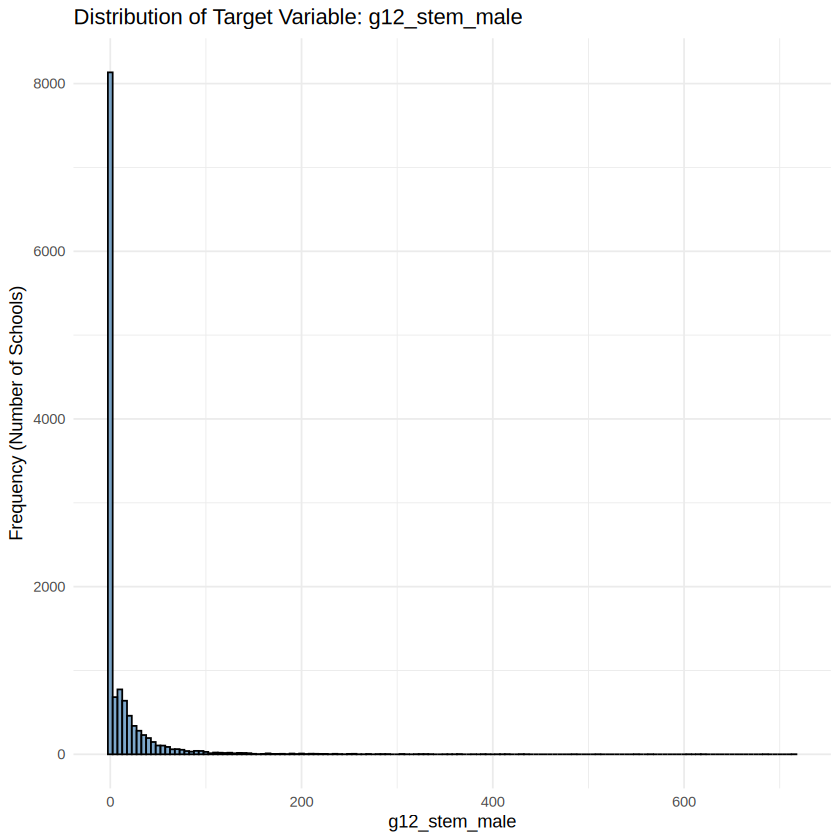

In [75]:
target_col <- "g12_stem_male"
if (!target_col %in% names(df)) {
  target_col <- names(df)[sapply(df, is.numeric)][1]
  cat("Note: 'g12_stem_male' not found explicitly. Using fallback target:", target_col, "\n")
}

target_summary <- summary(df[[target_col]])
print(target_summary)
cat("Standard Deviation:", sd(df[[target_col]], na.rm = TRUE), "\n")
cat("Interpretation: The target summary gives us the baseline central tendency and spread (mean vs. median).\n\n")

# Visualization 1: Histogram of Target Distribution with Interpretation Printed
p1 <- ggplot(df, aes_string(x = target_col)) +
  geom_histogram(binwidth = 5, fill = "steelblue", color = "black", alpha = 0.7) +
  labs(title = paste("Distribution of Target Variable:", target_col),
       x = target_col,
       y = "Frequency (Number of Schools)") +
  theme_minimal()
print(p1)

In [76]:
# (d) Missing Values, Duplicate Records, Unusual Values, and Outliers


In [78]:
total_nas <- sum(is.na(df))
cat("Total Missing Values in Dataset:", total_nas, "\n")

missing_per_col <- colSums(is.na(df))
if(sum(missing_per_col) > 0) {
  cat("Columns with missing values:\n")
  print(missing_per_col[missing_per_col > 0])
} else {
  cat("No missing values found in any column.\n")
}

total_duplicates <- sum(duplicated(df))
cat("Total Duplicate Rows:", total_duplicates, "\n\n")


Total Missing Values in Dataset: 1930600 
Columns with missing values:
               barangay          street_address             kinder_male 
                      7                      35                    1403 
          kinder_female                 g1_male               g1_female 
                   1403                    1403                    1403 
                g2_male               g2_female                 g3_male 
                   1403                    1403                    1403 
              g3_female                 g4_male               g4_female 
                   1403                    1403                    1403 
                g5_male               g5_female                 g6_male 
                   1403                    1403                    1403 
              g6_female               esng_male             esng_female 
                   1403                    1403                    1403 
                g7_male               g7_female      

In [79]:
# (e) Skewness, Outliers, and Issues Affecting Modeling


Warning message:
“Removed 47352 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


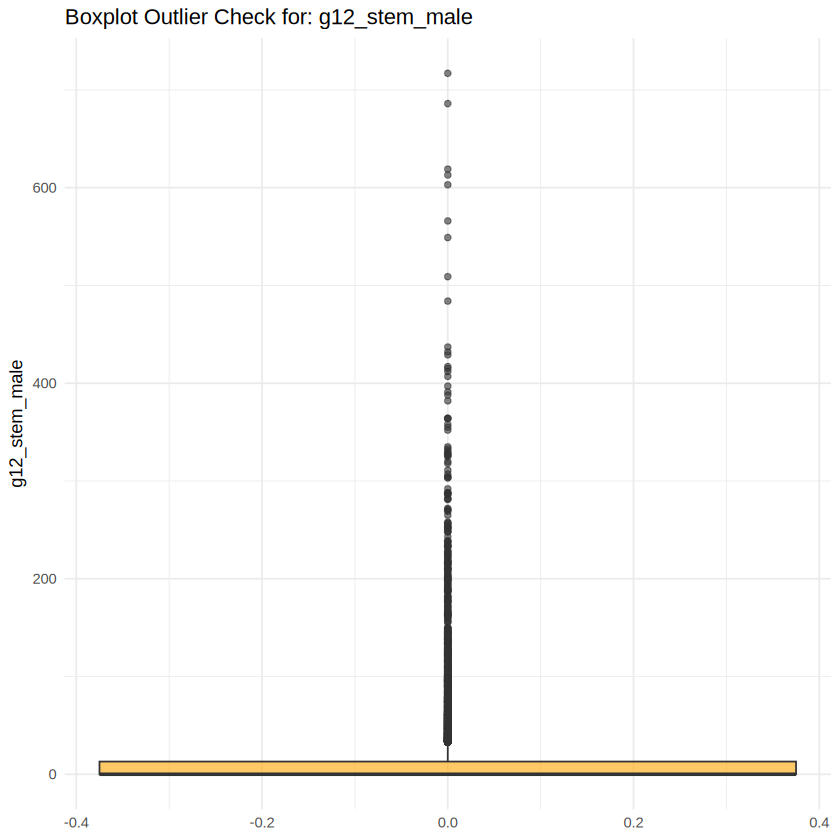

In [81]:
# Visualization 2: Boxplot for Outlier Detection
p2 <- ggplot(df, aes_string(y = target_col)) +
  geom_boxplot(fill = "orange", alpha = 0.6) +
  labs(title = paste("Boxplot Outlier Check for:", target_col),
       y = target_col) +
  theme_minimal()
print(p2)


In [89]:
# Check how many target values are missing
sum(is.na(data$g12_stem_male))

# Check percentage of missing target values
mean(is.na(data$g12_stem_male)) * 100

# Check frequency of target values
table(data$g12_stem_male, useNA = "ifany")

[1] 47352

[1] 78.65258


    0     1     2     3     4     5     6     7     8     9    10    11    12 
 7965    72    97   123   136   140   141   142   150   178   160   146   140 
   13    14    15    16    17    18    19    20    21    22    23    24    25 
  133   146   111   118   131    97   106    89    87    81    74    48    77 
   26    27    28    29    30    31    32    33    34    35    36    37    38 
   74    66    70    54    62    49    46    41    44    57    40    48    39 
   39    40    41    42    43    44    45    46    47    48    49    50    51 
   37    42    36    40    35    24    23    26    39    20    18    31    18 
   52    53    54    55    56    57    58    59    60    61    62    63    64 
   18    23    20    18    17    26    15    12    25    17    19    10    16 
   65    66    67    68    69    70    71    72    73    74    75    76    77 
   11    14     9    15    15    11    13     8    10    17    11    11     5 
   78    79    80    81    82    83    84    85    

In [85]:
# Look for variables containing "stem"
names(data)[grep("stem", names(data), ignore.case = TRUE)]

[1] "g11_stem_male"   "g11_stem_female" "g12_stem_male"   "g12_stem_female"

In [87]:
names(data)[grep("offer|strand|program|shs", names(data), ignore.case = TRUE)]

[1] "Modified Curricular Offering Classification"
[2] "offers_es"                                  
[3] "offers_jhs"                                 
[4] "offers_shs"                                 
[5] "g11_sshs_acad_male"                         
[6] "g11_sshs_acad_female"                       
[7] "g11_sshs_techpro_male"                      
[8] "g11_sshs_techpro_female"

In [90]:
data %>%
  select(g12_stem_male, contains("stem")) %>%
  head(20)

g12_stem_male,g11_stem_male,g11_stem_female,g12_stem_female
<dbl>,<dbl>,<dbl>,<dbl>
NA,NA,NA,NA
NA,NA,NA,NA
NA,NA,NA,NA
NA,NA,NA,NA
NA,NA,NA,NA
NA,NA,NA,NA
NA,NA,NA,NA
NA,NA,NA,NA
NA,NA,NA,NA


In [92]:
#Compare g12_stem_male with offers_shs
table(data$offers_shs, useNA = "ifany")


   No   Yes 
47232 12972 

In [95]:
table(
  data$offers_shs,
  is.na(data$g12_stem_male),
  useNA = "ifany"
)

     
      FALSE  TRUE
  No      0 47232
  Yes 12852   120

In [96]:
#| `offers_shs` | `g12_stem_male` available | `g12_stem_male` missing |
#|---|---:|---:|
#| No | 0 | 47,232 |
#| Yes | 12,852 | 120 |

In [97]:
#47,232 schools don't offer SHS → their g12_stem_male is always NA.
#12,852 schools offer SHS and have a reported target.
#Only 120 SHS schools have a missing g12_stem_male.


In [98]:
#Investigate the 120 missing SHS targets

In [100]:
data %>%
  filter(offers_shs == "Yes", is.na(g12_stem_male)) %>%
  select(
    school_id,
    school_name,
    offers_shs,
    g11_stem_male,
    g11_stem_female,
    g12_stem_male,
    g12_stem_female
  ) %>%
  head(30)

Warning message in FUN(X[[i]], ...):
“input string 2 is invalid in this locale”
Warning message in FUN(X[[i]], ...):
“input string 2 is invalid in this locale”
Warning message in FUN(X[[i]], ...):
“input string 2 is invalid in this locale”
ERROR while rich displaying an object: Error in gsub(chr, html_specials[[chr]], text, fixed = TRUE): input string 2 is invalid in this locale

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingH

school_id,school_name,offers_shs,g11_stem_male,g11_stem_female,g12_stem_male,g12_stem_female
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
304684,Philippine Science High School,Yes,NA,NA,NA,NA
400515,"Camella Snv School, Inc.",Yes,NA,NA,NA,NA
502194,Balong IS,Yes,NA,NA,NA,NA
300624,Bugkalot High School,Yes,NA,NA,NA,NA
411343,Mefats Aviation Academy Incorporated,Yes,NA,NA,NA,NA
400806,"Angelicum Academy of Heritage Marilao, Inc.",Yes,NA,NA,NA,NA
400964,Nuestra Se�ora del Carmen Institute,Yes,NA,NA,NA,NA
501812,Bagong Sikat Integrated School,Yes,NA,NA,NA,NA
306538,Zaragoza Senior High School,Yes,NA,NA,NA,NA


In [102]:
data %>%
  filter(offers_shs == "Yes", is.na(g12_stem_male)) %>%
  summarise(
    missing_g11_male = sum(is.na(g11_stem_male)),
    missing_g11_female = sum(is.na(g11_stem_female)),
    missing_g12_female = sum(is.na(g12_stem_female)),
    total = n()
  )

missing_g11_male,missing_g11_female,missing_g12_female,total
<int>,<int>,<int>,<int>
120,120,120,120


In [103]:
#120 SHS schools are not just missing g12_stem_male; all four STEM enrollment variables are missing

In [105]:
install.packages("tidymodels", dependencies = TRUE)
install.packages("ranger", dependencies = TRUE)

library(dplyr)
library(ggplot2)
library(tidymodels)
library(ranger)

In [106]:
#Conclusion:
#Group	Number	Interpretation
#SHS = No, target NA	47,232	Target is not applicable because school doesn't offer SHS
#SHS = Yes, target NA	120	STEM enrollment information is not reported/missing
#SHS = Yes, target observed	12,852	Valid modeling observations

In [107]:
#Primary model: Random Forest Regression

In [9]:
# 1. Install pre-compiled R binaries via system package manager
system("apt-get update && apt-get install -y r-cran-tidymodels r-cran-ranger", intern = TRUE)

# 2. Ensure R checks the system site library where apt installs packages
.libPaths(c("/usr/lib/R/site-library", "/usr/local/lib/R/site-library", .libPaths()))

# 3. Load libraries
library(dplyr)
library(ggplot2)
library(tidymodels)
library(ranger)
library(readr)

# Ensure the dataframe is loaded as 'df' and is not confused with the built-in df() function
if (!exists("df", mode = "list")) {
  df <- read_csv("/enrollment_2025-26.csv", show_col_types = FALSE)
}

# Create the modeling dataset using 'df'
data_model <- df %>%
  dplyr::filter(
    offers_shs == "Yes",
    !is.na(g12_stem_male)
  )

[1] "Get:1 https://cli.github.com/packages stable InRelease [3,917 B]"            
 [2] "Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease"                      
 [3] "Hit:3 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease"  
 [4] "Hit:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease"              
 [5] "Hit:5 http://archive.ubuntu.com/ubuntu noble-backports InRelease"            
 [6] "Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease"
 [7] "Hit:7 http://security.ubuntu.com/ubuntu noble-security InRelease"            
 [8] "Hit:8 https://r2u.stat.illinois.edu/ubuntu noble InRelease"                  
 [9] "Fetched 3,917 B in 1s (3,431 B/s)"                                           
[10] "Reading package lists..."                                                    
[11] "Reading package lists..."                                                    
[12] "Building dependency tree..."                                                 
[13] "Reading state information..."                                                
[14] "r-cran-tidymodels is already the newest version (1.5.0-1.ca2404.1)."         
[15] "r-cran-ranger is already the newest version (0.18.0-1.ca2404.1)."            
[16] "0 upgraded, 0 newly installed, 0 to remove and 64 not upgraded."

In [10]:
dim(data_model)

sum(is.na(data_model$g12_stem_male))

summary(data_model$g12_stem_male)

[1] 12852    83

[1] 0

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00    0.00   13.72   13.00  717.00 

In [11]:
#Explore the target
mean(data_model$g12_stem_male)

median(data_model$g12_stem_male)

sd(data_model$g12_stem_male)

sum(data_model$g12_stem_male == 0)

mean(data_model$g12_stem_male == 0) * 100


[1] 13.71506

[1] 0

[1] 37.50245

[1] 7965

[1] 61.97479

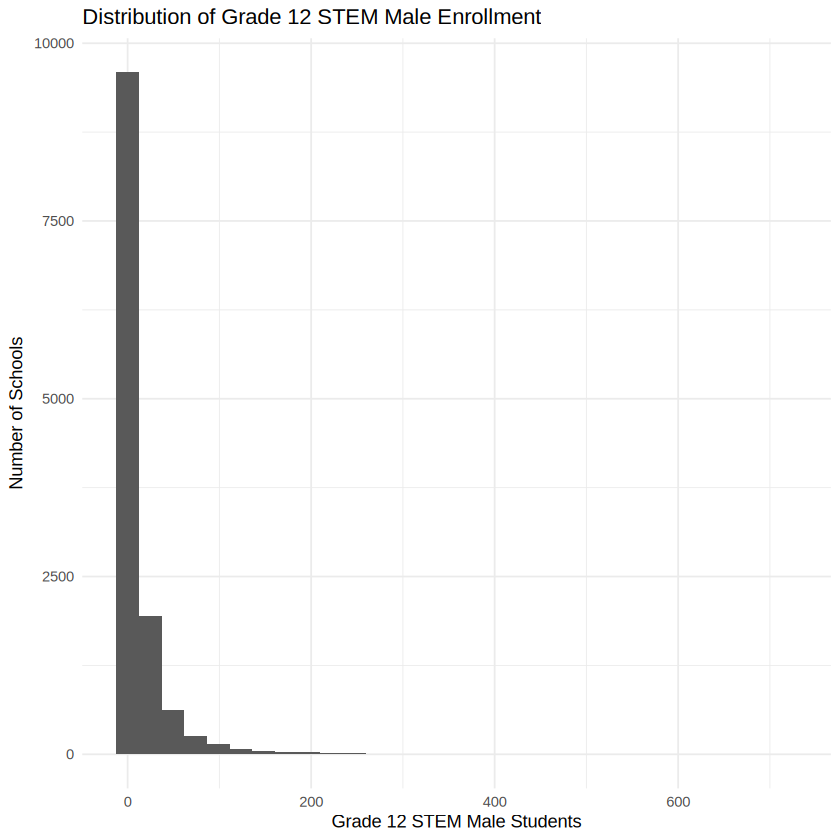

In [12]:
ggplot(data_model, aes(x = g12_stem_male)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Distribution of Grade 12 STEM Male Enrollment",
    x = "Grade 12 STEM Male Students",
    y = "Number of Schools"
  ) +
  theme_minimal()

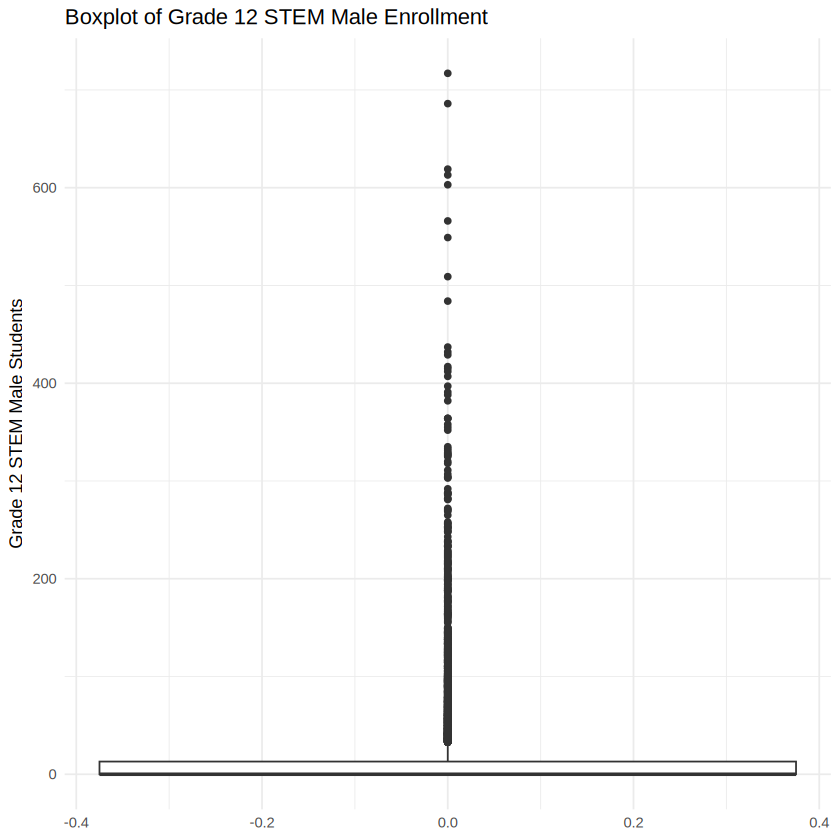

In [13]:
ggplot(data_model, aes(y = g12_stem_male)) +
  geom_boxplot() +
  labs(
    title = "Boxplot of Grade 12 STEM Male Enrollment",
    y = "Grade 12 STEM Male Students"
  ) +
  theme_minimal()

In [17]:
#Remove identifiers
names(data_model)


[1] "region"                                     
 [2] "division"                                   
 [3] "province"                                   
 [4] "school_district"                            
 [5] "legislative_district"                       
 [6] "municipality"                               
 [7] "barangay"                                   
 [8] "street_address"                             
 [9] "sector"                                     
[10] "school_management"                          
[11] "annex_status"                               
[12] "Modified Curricular Offering Classification"
[13] "offers_es"                                  
[14] "offers_jhs"                                 
[15] "offers_shs"                                 
[16] "kinder_male"                                
[17] "kinder_female"                              
[18] "g1_male"                                    
[19] "g1_female"                                  
[20] "g2_male"                                    
[21] "g2_female"                                  
[22] "g3_male"                                    
[23] "g3_female"                                  
[24] "g4_male"                                    
[25] "g4_female"                                  
[26] "g5_male"                                    
[27] "g5_female"                                  
[28] "g6_male"                                    
[29] "g6_female"                                  
[30] "esng_male"                                  
[31] "esng_female"                                
[32] "g7_male"                                    
[33] "g7_female"                                  
[34] "g8_male"                                    
[35] "g8_female"                                  
[36] "g9_male"                                    
[37] "g9_female"                                  
[38] "g10_male"                                   
[39] "g10_female"                                 
[40] "jhsng_male"                                 
[41] "jhsng_female"                               
[42] "g11_abm_male"                               
[43] "g11_abm_female"                             
[44] "g11_arts_male"                              
[45] "g11_arts_female"                            
[46] "g11_gas_male"                               
[47] "g11_gas_female"                             
[48] "g11_humss_male"                             
[49] "g11_humss_female"                           
[50] "g11_maritime_male"                          
[51] "g11_maritime_female"                        
[52] "g11_sports_male"                            
[53] "g11_sports_female"                          
[54] "g11_stem_male"                              
[55] "g11_stem_female"                            
[56] "g11_tvl_male"                               
[57] "g11_tvl_female"                             
[58] "g11_unique_male"                            
[59] "g11_unique_female"                          
[60] "g11_sshs_acad_male"                         
[61] "g11_sshs_acad_female"                       
[62] "g11_sshs_techpro_male"                      
[63] "g11_sshs_techpro_female"                    
[64] "g12_abm_male"                               
[65] "g12_abm_female"                             
[66] "g12_arts_male"                              
[67] "g12_arts_female"                            
[68] "g12_gas_male"                               
[69] "g12_gas_female"                             
[70] "g12_humss_male"                             
[71] "g12_humss_female"                           
[72] "g12_maritime_male"                          
[73] "g12_maritime_female"                        
[74] "g12_sports_male"                            
[75] "g12_sports_female"                          
[76] "g12_stem_male"                              
[77] "g12_stem_female"                            
[78] "g12_tvl_male"                               
[79] "g12_tvl_female"  

In [22]:
data_model <- data_model %>%
  select(
    -any_of(c("school_id", "school_name"))
  )

In [25]:
#Look at all Grade 12 variables:
names(data_model)[grep("^g12_", names(data_model), ignore.case = TRUE)]

[1] "g12_abm_male"        "g12_abm_female"      "g12_arts_male"      
 [4] "g12_arts_female"     "g12_gas_male"        "g12_gas_female"     
 [7] "g12_humss_male"      "g12_humss_female"    "g12_maritime_male"  
[10] "g12_maritime_female" "g12_sports_male"     "g12_sports_female"  
[13] "g12_stem_male"       "g12_stem_female"     "g12_tvl_male"       
[16] "g12_tvl_female"      "g12_unique_male"     "g12_unique_female"

In [28]:
#Remove Column
names(data_model)[grep("^g11_", names(data_model), ignore.case = TRUE)]

names(data_model)[grep("^g12_", names(data_model), ignore.case = TRUE)]

[1] "g11_abm_male"            "g11_abm_female"         
 [3] "g11_arts_male"           "g11_arts_female"        
 [5] "g11_gas_male"            "g11_gas_female"         
 [7] "g11_humss_male"          "g11_humss_female"       
 [9] "g11_maritime_male"       "g11_maritime_female"    
[11] "g11_sports_male"         "g11_sports_female"      
[13] "g11_stem_male"           "g11_stem_female"        
[15] "g11_tvl_male"            "g11_tvl_female"         
[17] "g11_unique_male"         "g11_unique_female"      
[19] "g11_sshs_acad_male"      "g11_sshs_acad_female"   
[21] "g11_sshs_techpro_male"   "g11_sshs_techpro_female"

[1] "g12_abm_male"        "g12_abm_female"      "g12_arts_male"      
 [4] "g12_arts_female"     "g12_gas_male"        "g12_gas_female"     
 [7] "g12_humss_male"      "g12_humss_female"    "g12_maritime_male"  
[10] "g12_maritime_female" "g12_sports_male"     "g12_sports_female"  
[13] "g12_stem_male"       "g12_stem_female"     "g12_tvl_male"       
[16] "g12_tvl_female"      "g12_unique_male"     "g12_unique_female"

In [31]:
missing_percent <- data.frame(
  variable = names(data_model),
  missing = colSums(is.na(data_model)),
  missing_percent = colMeans(is.na(data_model)) * 100
) %>%
  arrange(desc(missing_percent))

missing_percent

,variable,missing,missing_percent
,<chr>,<dbl>,<dbl>
kinder_male,kinder_male,1357,10.55866791
kinder_female,kinder_female,1357,10.55866791
g1_male,g1_male,1357,10.55866791
g1_female,g1_female,1357,10.55866791
g2_male,g2_male,1357,10.55866791
g2_female,g2_female,1357,10.55866791
g3_male,g3_male,1357,10.55866791
g3_female,g3_female,1357,10.55866791
g4_male,g4_male,1357,10.55866791


In [33]:
#80% training / 20% testing

set.seed(516)

data_split <- initial_split(
  data_model,
  prop = 0.80
)

train_data <- training(data_split)
test_data <- testing(data_split)

In [34]:
nrow(train_data)

nrow(test_data)

[1] 10281

[1] 2571

In [35]:
median(data_model$some_variable, na.rm = TRUE)

Warning message:
“Unknown or uninitialised column: `some_variable`.”


NULL

In [37]:
#REMOVE TARGET-LEAKAGE VARIABLES
g12_predictors <- names(data_model)[
  grepl("^g12_", names(data_model), ignore.case = TRUE)
]

g12_predictors <- setdiff(
  g12_predictors,
  "g12_stem_male"
)

g12_predictors

[1] "g12_abm_male"        "g12_abm_female"      "g12_arts_male"      
 [4] "g12_arts_female"     "g12_gas_male"        "g12_gas_female"     
 [7] "g12_humss_male"      "g12_humss_female"    "g12_maritime_male"  
[10] "g12_maritime_female" "g12_sports_male"     "g12_sports_female"  
[13] "g12_stem_female"     "g12_tvl_male"        "g12_tvl_female"     
[16] "g12_unique_male"     "g12_unique_female"

In [38]:
data_model <- data_model %>%
  select(-all_of(g12_predictors))


In [39]:
names(data_model)[
  grep("^g12_", names(data_model), ignore.case = TRUE)
]

[1] "g12_stem_male"

In [42]:
#Check missing predictors
missing_table <- data.frame(
  variable = names(data_model),
  missing = colSums(is.na(data_model)),
  missing_percent = colMeans(is.na(data_model)) * 100
) %>%
  arrange(desc(missing_percent))

missing_table

,variable,missing,missing_percent
,<chr>,<dbl>,<dbl>
kinder_male,kinder_male,1357,10.55866791
kinder_female,kinder_female,1357,10.55866791
g1_male,g1_male,1357,10.55866791
g1_female,g1_female,1357,10.55866791
g2_male,g2_male,1357,10.55866791
g2_female,g2_female,1357,10.55866791
g3_male,g3_male,1357,10.55866791
g3_female,g3_female,1357,10.55866791
g4_male,g4_male,1357,10.55866791


In [43]:
#TRAIN / TEST SPLIT
set.seed(516)

data_split <- initial_split(
  data_model,
  prop = 0.80
)

train_data <- training(data_split)
test_data <- testing(data_split)

nrow(train_data)
nrow(test_data)

[1] 10281

[1] 2571

In [46]:
#Identify categorical variables
names(train_data)[
  sapply(train_data, is.character)
]

[1] "region"                                     
 [2] "division"                                   
 [3] "province"                                   
 [4] "school_district"                            
 [5] "legislative_district"                       
 [6] "municipality"                               
 [7] "barangay"                                   
 [8] "street_address"                             
 [9] "sector"                                     
[10] "school_management"                          
[11] "annex_status"                               
[12] "Modified Curricular Offering Classification"
[13] "offers_es"                                  
[14] "offers_jhs"                                 
[15] "offers_shs"

In [70]:
#PREPROCESSING RECIPE
rf_recipe <- recipe(
  g12_stem_male ~ .,
  data = train_data
) %>%
  step_rm(
    any_of(c("offers_shs", "street_address", "barangay", "school_district", "municipality"))
  ) %>%
  step_impute_median(
    all_numeric_predictors()
  ) %>%
  step_impute_mode(
    all_nominal_predictors()
  ) %>%
  step_dummy(
    all_nominal_predictors()
  ) %>%
  step_zv(
    all_predictors()
  )

In [49]:
# Summary of Preprocessing Steps applied to the recipe above:
# 1. Numeric missing values: Imputed using step_impute_median()
# 2. Categorical missing values: Imputed using step_impute_mode()
# 3. Categorical encoding: Dummy variables created using step_dummy()
# 4. Filter zero-variance predictors: Removed using step_zv()

In [ ]:
#Random Forest does not require scaling.

#Observation: The dataset contains numeric and categorical predictors with different measurement scales.
#Method: Numeric predictors were not standardized or normalized.
#Reason: Random Forest is a tree-based algorithm and does not depend on distances or coefficient magnitudes. Therefore, scaling is unnecessary.
#Training-only fitting: Not applicable because no scaling parameters were estimated.

In [60]:
# CLEAN ENCODING & INSPECT EXTREME TARGET
# Using iconv to replace any invalid multibyte characters with spaces so Colab can render the table safely
data_model %>%
  mutate(across(where(is.character), ~iconv(.x, from = "UTF-8", to = "ASCII//TRANSLIT", sub = " "))) %>%
  arrange(desc(g12_stem_male)) %>%
  select(g12_stem_male, everything()) %>%
  head(20)

g12_stem_male,region,division,province,school_district,legislative_district,municipality,barangay,street_address,sector,⋯,g11_stem_male,g11_stem_female,g11_tvl_male,g11_tvl_female,g11_unique_male,g11_unique_female,g11_sshs_acad_male,g11_sshs_acad_female,g11_sshs_techpro_male,g11_sshs_techpro_female
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
717,NCR,Quezon City,NCR SECOND DISTRICT,School District X,2nd District,QUEZON CITY,GREATER LAGRO,"Hilltop Mansion, Lagro, Quezon City",Private,⋯,605,756,0,0,0,0,0,0,0,0
686,Region X,Cagayan de Oro City,MISAMIS ORIENTAL,Cagayan de Oro City Central I District,1st District,CAGAYAN DE ORO CITY (Capital),CARMEN,"waling-waling, carmen",Private,⋯,764,869,219,81,0,0,0,0,0,0
619,NCR,Valenzuela City,NCR THIRD DISTRICT,Valenzuela City South District,2nd District,CITY OF VALENZUELA,MARULAS,"Fatima Avenue, Pag-asa Subd. Marulas",Private,⋯,480,586,0,0,0,0,0,0,0,0
613,NCR,Pasig City,NCR SECOND DISTRICT,Pasig City District V,Lone District,CITY OF PASIG,CANIOGAN,Pag-Asa Street,Private,⋯,550,459,772,517,0,0,0,0,0,0
603,Region IV-A,Dasmarinas City,CAVITE,Dasmari as I,4th District,CITY OF DASMARI AS,SAMPALOC I,Sampaloc I,Private,⋯,539,581,740,433,0,0,0,0,0,0
566,NCR,Manila,"MANILA, NCR, FIRST DISTRICT",Tondo I,4th District,SAN MIGUEL,BARANGAY 637,2600 Legarda St. Sampaloc Manila,Private,⋯,546,447,426,292,0,0,0,0,0,0
549,Region III,Malolos City,BULACAN,North District,1st District,CITY OF MALOLOS (Capital),CATMON,Catmon City of Malolos,Private,⋯,0,0,1,0,0,0,666,780,252,275
509,Region IV-A,Antipolo City,RIZAL,District I-A,1st District,CITY OF ANTIPOLO,SANTA CRUZ,Sumulong Highway,Private,⋯,629,634,0,0,0,0,0,0,0,0
484,Region III,Pampanga,PAMPANGA,Guagua East,2nd District,GUAGUA,SANTA FILOMENA (POB.),Rep. E. Lagman Street,Private,⋯,420,391,0,0,0,0,0,0,0,0


In [52]:
#Observation: The target contains large values, with a maximum of 717 students.
#Method: Extreme observations were reviewed rather than automatically removed.
#Reason: Large enrollment values can represent legitimate large schools rather than data errors. Removing them could eliminate meaningful observations. Random Forest is also relatively robust to extreme values.
#Decision: Legitimate extreme observations were retained.

In [54]:
# RANDOM FOREST REGRESSION
rf_model <- rand_forest(
  trees = 500,
  mtry = 5,
  min_n = 5
) %>%
  set_engine("ranger") %>%
  set_mode("regression")

In [56]:
# MODEL WORKFLOW
rf_workflow <- workflow() %>%
  add_recipe(rf_recipe) %>%
  add_model(rf_model)

In [72]:
set.seed(516)

# Clean character column encodings to prevent dummy variable naming errors
clean_encoding <- function(x) {
  if (is.character(x)) {
    iconv(x, from = "UTF-8", to = "ASCII//TRANSLIT", sub = "")
  } else {
    x
  }
}

train_data <- train_data %>% mutate(across(everything(), clean_encoding))
test_data  <- test_data  %>% mutate(across(everything(), clean_encoding))

# Re-create workflow with updated recipe
rf_workflow <- workflow() %>%
  add_recipe(rf_recipe) %>%
  add_model(rf_model)

# Fit the model successfully
rf_fit <- rf_workflow %>%
  fit(data = train_data)

In [74]:
# TEST SET PREDICTIONS
rf_predictions <- predict(
  rf_fit,
  new_data = test_data
) %>%
  bind_cols(
    test_data %>%
      select(g12_stem_male)
  )

head(rf_predictions)

Warning message:
“! There are new levels in `division`: "Kingdom of Bahrain" and "Italy".
ℹ Consider using step_novel() (`?recipes::step_novel()`) before `step_dummy()`
  to handle unseen values.”
Warning message:
“! There are new levels in `province`: "(SGA - North Cotabato)".
ℹ Consider using step_novel() (`?recipes::step_novel()`) before `step_dummy()`
  to handle unseen values.”
Warning message:
“! There are new levels in `legislative_district`: "No Legislative District".
ℹ Consider using step_novel() (`?recipes::step_novel()`) before `step_dummy()`
  to handle unseen values.”
Warning message:
“! There are new levels in `annex_status`: "Mobile School(s)/Center(s)".
ℹ Consider using step_novel() (`?recipes::step_novel()`) before `step_dummy()`
  to handle unseen values.”


.pred,g12_stem_male
<dbl>,<dbl>
1.762634,0
7.939716,17
3.692559,8
7.068515,8
3.722803,9
4.545858,9


In [76]:
# MODEL EVALUATION
rmse_result <- rmse(
  rf_predictions,
  truth = g12_stem_male,
  estimate = .pred
)

rmse_result

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,22.98172


In [78]:
mae_result <- mae(
  rf_predictions,
  truth = g12_stem_male,
  estimate = .pred
)

mae_result

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
mae,standard,9.768967


In [79]:
# ACTUAL VS PREDICTED

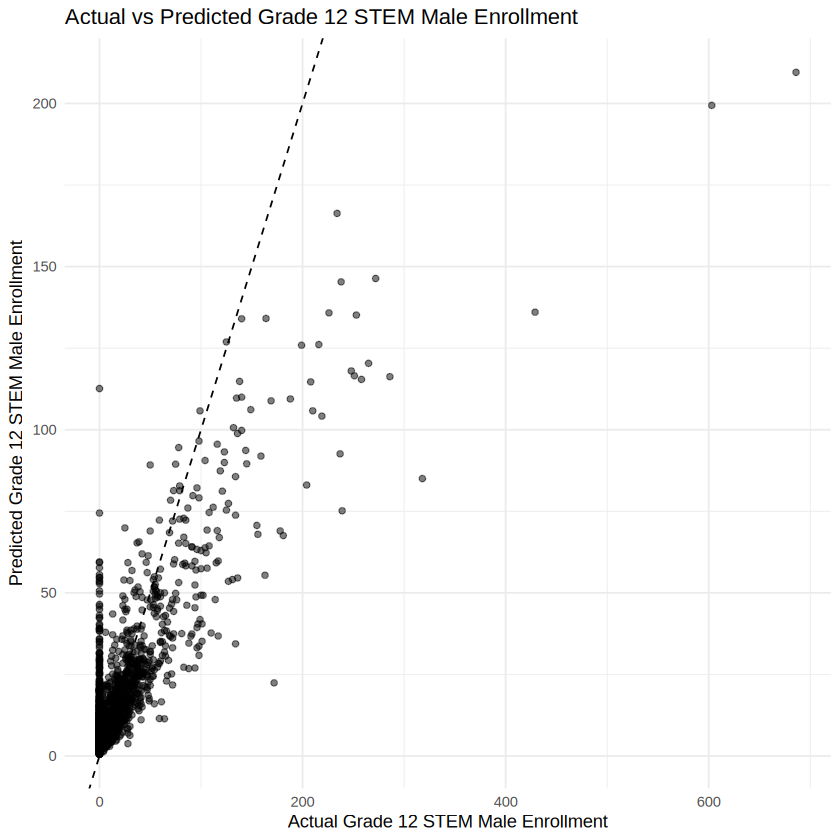

In [81]:
# ACTUAL VS PREDICTED
#Final visualization #1
ggplot(
  rf_predictions,
  aes(
    x = g12_stem_male,
    y = .pred
  )
) +
  geom_point(alpha = 0.5) +
  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = "dashed"
  ) +
  labs(
    title = "Actual vs Predicted Grade 12 STEM Male Enrollment",
    x = "Actual Grade 12 STEM Male Enrollment",
    y = "Predicted Grade 12 STEM Male Enrollment"
  ) +
  theme_minimal()

In [83]:
#Final visualization #2 — Residual plot
rf_predictions <- rf_predictions %>%
  mutate(
    residual = g12_stem_male - .pred
  )

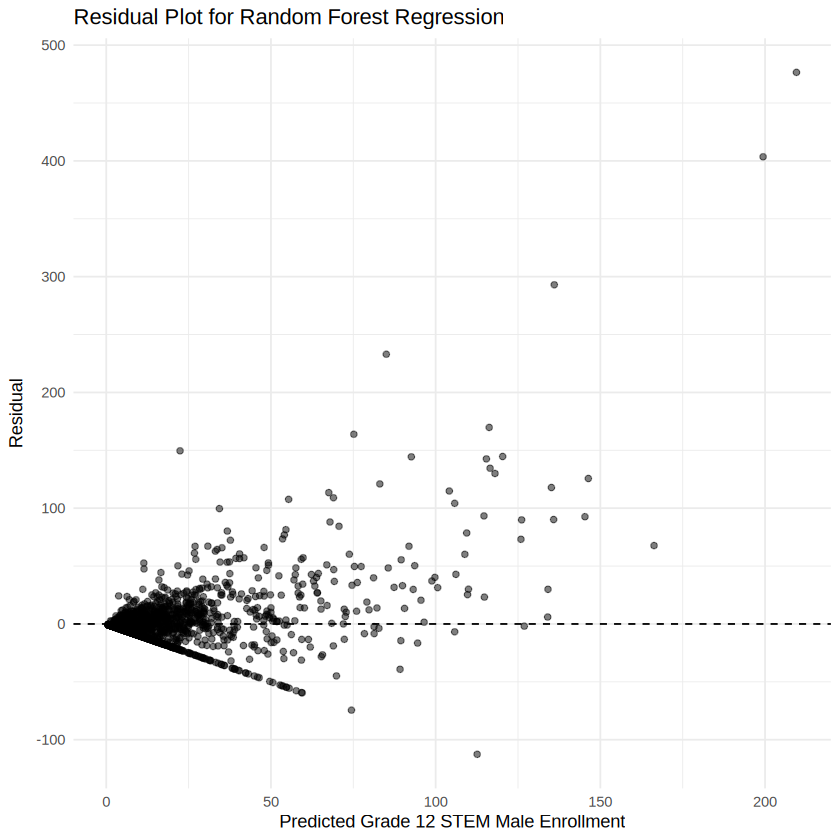

In [84]:
ggplot(
  rf_predictions,
  aes(
    x = .pred,
    y = residual
  )
) +
  geom_point(alpha = 0.5) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    title = "Residual Plot for Random Forest Regression",
    x = "Predicted Grade 12 STEM Male Enrollment",
    y = "Residual"
  ) +
  theme_minimal()

In [85]:
#RANDOM FOREST WITH FEATURE IMPORTANCE
rf_model_importance <- rand_forest(
  trees = 500,
  mtry = 5,
  min_n = 5
) %>%
  set_engine(
    "ranger",
    importance = "impurity"
  ) %>%
  set_mode("regression")

In [86]:
rf_workflow_importance <- workflow() %>%
  add_recipe(rf_recipe) %>%
  add_model(rf_model_importance)

In [87]:
set.seed(516)

rf_fit_importance <- rf_workflow_importance %>%
  fit(data = train_data)

In [ ]:
install.packages("vip")
library(vip)

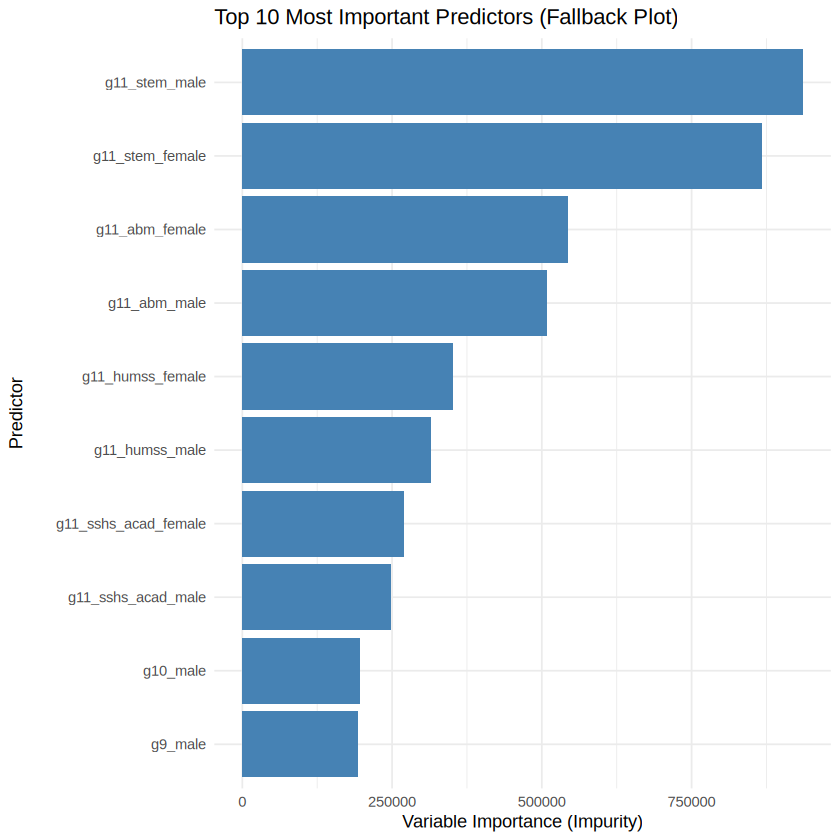

In [91]:
# Fallback variable importance visualization without relying on the 'vip' package
imp_vals <- extract_fit_parsnip(rf_fit_importance)$fit$variable.importance

imp_df <- data.frame(
  variable = names(imp_vals),
  importance = as.numeric(imp_vals)
) %>%
  dplyr::slice_max(importance, n = 10)

ggplot(imp_df, aes(x = reorder(variable, importance), y = importance)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top 10 Most Important Predictors (Fallback Plot)",
    x = "Predictor",
    y = "Variable Importance (Impurity)"
  ) +
  theme_minimal()

In [92]:
# ==========================================
# FEATURE IMPORTANCE TABLE
# ==========================================

importance_values <- extract_fit_parsnip(
  rf_fit_importance
)$fit$variable.importance

importance_df <- data.frame(
  variable = names(importance_values),
  importance = as.numeric(importance_values)
) %>%
  arrange(desc(importance))

head(importance_df, 20)

,variable,importance
,<chr>,<dbl>
1,g11_stem_male,935720.6
2,g11_stem_female,867009.5
3,g11_abm_female,543210.2
4,g11_abm_male,508497.4
5,g11_humss_female,350993.0
6,g11_humss_male,314835.6
7,g11_sshs_acad_female,270001.1
8,g11_sshs_acad_male,248581.3
9,g10_male,196725.1


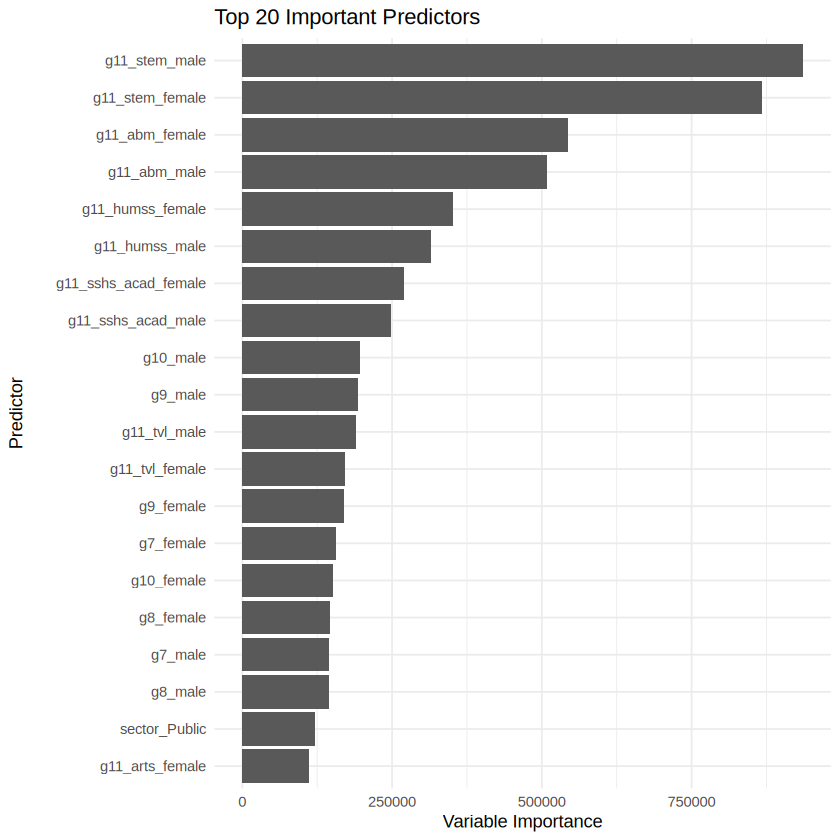

In [93]:
ggplot(
  head(importance_df, 20),
  aes(
    x = reorder(variable, importance),
    y = importance
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 20 Important Predictors",
    x = "Predictor",
    y = "Variable Importance"
  ) +
  theme_minimal()